# DUET · Predictor Track — Week 2 (final)

**Waqar Akmal** · Predictor & Analysis Lead · *Qwen2.5-Math-1.5B + GSM8K, verl GRPO*

**What I'm doing this week (in one line):** measure which cheap prompt-text features predict
how a prompt will behave when run — its response **length** and its **difficulty** — so my
predictor can feed Samuel's scheduler.

**The flow of this notebook, top to bottom:**
`prompt text → features` · `raw rollouts → per-prompt targets` · `correlate features vs targets`




## 0. Setup

In [1]:
import json, urllib.request, glob, os, re
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

np.random.seed(0)   # fixed seed so a clean run always gives the same numbers

# Real GSM8K test set (1319 problems), pulled over HTTP so there's no auth / no local file.
URL = ("https://raw.githubusercontent.com/openai/grade-school-math/master/"
       "grade_school_math/data/test.jsonl")
raw = urllib.request.urlopen(URL).read().decode()
PROMPTS = [json.loads(line)["question"] for line in raw.strip().split("\n")]
print(f"Loaded {len(PROMPTS)} real GSM8K prompts")

Loaded 1319 real GSM8K prompts


## 1. `features.py` — the inputs (computed from prompt text ONLY)

**My hard rule:** every feature is computable from the raw prompt text, before any rollout.
At prediction time the scheduler has run **zero** rollouts, so text is all I have. Anything I'd
only learn by generating (length, score, difficulty) is an OUTPUT I predict, never an INPUT.

**Single source of truth:** this same `extract()` goes into the online predictor (Week 5), so
offline study and production can't drift apart.

These 10 features are **hypotheses** — cheap proxies I *think* might track length/difficulty.
Which ones actually do is what Section 9 measures.

In [2]:
# ================= features.py =================
OP_WORDS = ["times","divided","multiply","product","sum","difference","remainder",
            "proportion","proportional","percent","ratio","average","per","total",
            "twice","half","double","triple","each","combined","increase","decrease"]
HARD_CUES = ["remainder","proportion","proportional","percent","ratio","average",
             "rate","prove","derive","consecutive","profit","discount","interest"]
NUMBER_RE    = re.compile(r"\$?\d+(?:\.\d+)?%?")   # 16, 3.5, $2, 25%
OP_SYMBOL_RE = re.compile(r"[+\-*/=×÷]")

def extract(prompt: str) -> dict:
    """My 10 prompt-side features for ONE prompt. Reads only the text."""
    text  = prompt.strip()
    lower = text.lower()
    words = re.findall(r"\b\w+\b", text)
    sentences = [s for s in re.split(r"[.?!]+", text) if s.strip()]
    return {
        "n_chars":      len(text),                              # raw length
        "n_words":      len(words),                             # my main length proxy
        "n_sentences":  len(sentences),                         # stacked conditions
        "n_numbers":    len(NUMBER_RE.findall(text)),           # quantities to combine
        "n_op_symbols": len(OP_SYMBOL_RE.findall(text)),        # +,-,x,= (rare in GSM8K)
        "n_op_words":   sum(lower.count(w) for w in OP_WORDS),  # worded operations
        "n_questions":  text.count("?"),
        "n_commas":     text.count(","),                        # clause proxy
        "avg_word_len": float(np.mean([len(w) for w in words])) if words else 0.0,
        "n_hard_cues":  sum(lower.count(c) for c in HARD_CUES),
    }

def build_table(prompts) -> pd.DataFrame:
    """Many prompts -> one feature DataFrame (one row per prompt)."""
    return pd.DataFrame([extract(p) for p in prompts])

# quick look on the real prompts
feats_preview = build_table(PROMPTS)
print(f"{feats_preview.shape[1]} features over {feats_preview.shape[0]} prompts")
feats_preview.describe().round(2).T[["mean","std","min","max"]]

10 features over 1319 prompts


,mean,std,min,max
n_chars,239.87,97.61,73.00,848.00
n_words,47.10,18.36,15.00,165.00
n_sentences,3.68,1.38,1.00,13.00
n_numbers,3.47,1.72,0.00,13.00
n_op_symbols,0.31,0.80,0.00,12.00
n_op_words,1.71,1.50,0.00,11.00
n_questions,0.95,0.21,0.00,1.00
n_commas,1.62,1.59,0.00,11.00
avg_word_len,3.95,0.38,2.98,5.83
n_hard_cues,0.17,0.51,0.00,6.00


## 2. `correlate.py` — aggregation + correlation

Two jobs. `aggregate_rollouts` collapses the raw per-rollout rows (5 per prompt) into per-prompt
targets. `correlation_report` scores every feature against every target with **both** Pearson
(straight-line) and Spearman (rank/curved), keeping whichever is stronger.

**Two guards, because a correlation is only meaningful if BOTH sides vary:**
- if a **feature** is constant → skip (a flat input can't explain anything)
- if a **target** is constant → skip (this is the all-zero-reward trap: correlating against a
  flat target gives a fake ~0, not a real finding). I return NaN and warn instead.

In [3]:
# ================= correlate.py =================
def aggregate_rollouts(rollouts: pd.DataFrame, key: str) -> pd.DataFrame:
    """Raw per-rollout rows -> per-prompt targets. Each group = the 5 rollouts of one prompt."""
    g = rollouts.groupby(key)
    return pd.DataFrame({
        "mean_resp_len": g["resp_len"].mean(),                          # -> length head
        "pass_rate":     g["score"].mean(),                             # difficulty: how often it passes
        "reward_var":    g["score"].var(ddof=0),                        # difficulty: within-group disagreement = p(1-p)
        "frac_capped":   g["resp_len"].apply(lambda s: (s >= 1024).mean()),  # censoring diagnostic
        "n_rollouts":    g["score"].size(),                             # sanity: should be ~5
    }).reset_index()

def correlation_report(features: pd.DataFrame, outcomes: pd.DataFrame, targets) -> pd.DataFrame:
    joined = pd.concat([features.reset_index(drop=True),
                        outcomes[targets].reset_index(drop=True)], axis=1)
    rows = []
    for target in targets:
        y = joined[target]
        if y.nunique() < 2 or y.std() == 0:            # TARGET guard (the trap I hit before)
            print(f"  [warn] target '{target}' has no variation -> correlations undefined, skipping.")
            for f in features.columns:
                rows.append({"target":target,"feature":f,"pearson":float("nan"),
                             "spearman":float("nan"),"max_abs":float("nan")})
            continue
        for f in features.columns:
            x = joined[f]
            if x.nunique() < 2:                         # FEATURE guard (constant input)
                pear = spear = float("nan")
            else:
                pear  = pearsonr(x, y).statistic
                spear = spearmanr(x, y).statistic
            rows.append({"target":target,"feature":f,
                         "pearson":round(pear,3),"spearman":round(spear,3),
                         "max_abs":round(max(abs(pear),abs(spear)),3)})
    return pd.DataFrame(rows).sort_values(["target","max_abs"], ascending=[True,False])

def top_features(report, target, k=3):
    return report[report.target==target].head(k)

## 3. What "difficulty" means here — the dead-group U-curve

Difficulty is **not** "how likely to fail." It's "will this prompt produce a dead group" — a
group where all 5 rollouts agree, so advantage is zero, so the gradient is zero, so it teaches
nothing (even though I paid full compute). For a 0/1 reward, within-group disagreement is
`p(1-p)`: zero at both extremes (all-fail p=0, all-pass p=1), maximum in the middle (p=0.5).
So difficulty is a **hump**, and both ends are dead.

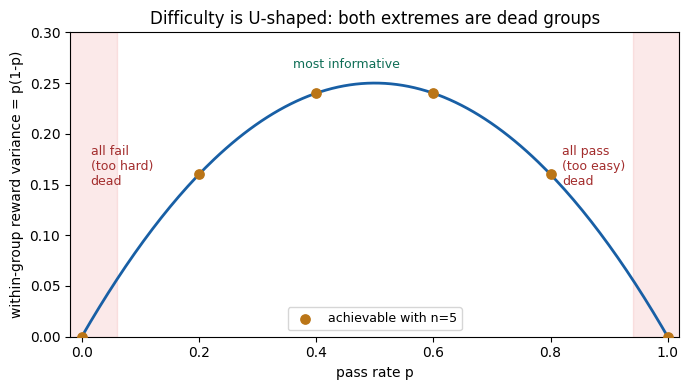

In [4]:
import matplotlib.pyplot as plt
p = np.linspace(0,1,200); var = p*(1-p)
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(p, var, color="#185FA5", lw=2)
p5 = np.array([0,.2,.4,.6,.8,1.0])
ax.scatter(p5, p5*(1-p5), color="#BA7517", zorder=5, s=45, label="achievable with n=5")
ax.axvspan(-0.02,0.06, color="#E24B4A", alpha=0.12); ax.axvspan(0.94,1.02, color="#E24B4A", alpha=0.12)
ax.annotate("all fail\n(too hard)\ndead", xy=(0,0), xytext=(0.015,0.15), fontsize=9, color="#A32D2D")
ax.annotate("all pass\n(too easy)\ndead", xy=(1,0), xytext=(0.82,0.15), fontsize=9, color="#A32D2D")
ax.annotate("most informative", xy=(0.5,0.25), xytext=(0.36,0.265), fontsize=9, color="#0F6E56")
ax.set_xlabel("pass rate p"); ax.set_ylabel("within-group reward variance = p(1-p)")
ax.set_title("Difficulty is U-shaped: both extremes are dead groups")
ax.set_xlim(-0.02,1.02); ax.set_ylim(0,0.30); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 4. Upload Samuel's rollout files

I get the `.jsonl` files from the Modal dashboard (Storage → `duet-volume` →
`traces/rollout_data/`) or from Samuel, and upload them here. Real schema (verified, not the
doc): `input, output, gts, score, step, acc` — 5 rollouts per prompt, no `resp_len` column
(I derive it), and an `acc` column the doc never mentioned.

In [5]:
# NOTE TO SELF: upload each file ONCE. If old copies are still in the folder,
# Colab keeps both as "1 (1).jsonl" etc. and discovery loads duplicates -> n_rollouts
# comes out as a multiple of 5 (e.g. 10). Harmless to the stats (means/variances are
# unchanged by duplication) but the count is wrong. To reset: !rm -rf ./duet_data

# Built-in uploader — click "Choose Files" and pick the .jsonl files.
UPLOAD_HERE = True   # set False if I already dragged files into Colab's file panel

if UPLOAD_HERE:
    try:
        from google.colab import files
        os.makedirs("./duet_data/rollout_data", exist_ok=True)
        print("Pick the rollout .jsonl files (I can select several)...")
        up = files.upload()
        for fn in up:
            os.replace(fn, f"./duet_data/rollout_data/{fn}")
            print("  placed ->", fn)
    except ModuleNotFoundError:
        print("Not on Colab — using files already in the working directory.")
else:
    print("UPLOAD_HERE False — using files already present.")

Pick the rollout .jsonl files (I can select several)...


Saving 3 (2).jsonl to 3 (2).jsonl
Saving 2 (1).jsonl to 2 (1).jsonl
Saving 1 (1).jsonl to 1 (1).jsonl
  placed -> 3 (2).jsonl
  placed -> 2 (1).jsonl
  placed -> 1 (1).jsonl


In [6]:
# Find the files wherever they landed (I search several spots so a stray path doesn't
# silently drop me to synthetic data).
SEARCH = ["./duet_data/rollout_data/*.jsonl","./rollout_data/*.jsonl",
          "./*.jsonl","/content/*.jsonl","/content/**/*.jsonl"]
def find_files():
    seen=[]
    for pat in SEARCH:
        for h in sorted(glob.glob(pat, recursive=True)):
            if "checkpoint" not in h.lower() and h not in seen: seen.append(h)
    return seen
ROLLOUT_FILES = find_files()
print("jsonl files found:")
for f in ROLLOUT_FILES: print("  ", f)
if not ROLLOUT_FILES: print("  (none — will fall back to synthetic in Section 6)")

jsonl files found:
   ./duet_data/rollout_data/1 (1).jsonl
   ./duet_data/rollout_data/2 (1).jsonl
   ./duet_data/rollout_data/3 (2).jsonl
   /content/duet_data/rollout_data/1 (1).jsonl
   /content/duet_data/rollout_data/2 (1).jsonl
   /content/duet_data/rollout_data/3 (2).jsonl


## 5. Inspect one real row (before trusting anything)

I confirm the field names and that `score`/`acc` are really 0/1 with my own eyes.

In [7]:
if ROLLOUT_FILES:
    _p = pd.read_json(ROLLOUT_FILES[0], lines=True)
    print("shape:", _p.shape, " (rows should be a multiple of 5)")
    print("columns:", _p.columns.tolist())
    for col in ["score","acc"]:
        if col in _p.columns: print(f"{col}:", _p[col].value_counts().to_dict())
    display(_p.head(1).T)
else:
    print("No files yet — Section 6 falls back to synthetic.")

shape: (2560, 6)  (rows should be a multiple of 5)
columns: ['input', 'output', 'gts', 'score', 'step', 'acc']
score: {0: 2016, 1: 544}
acc: {0: 2016, 1: 544}


,0
input,"system\nPlease reason step by step, and put yo..."
output,come....\n_OTHER
gts,28
score,0
step,1
acc,0


## 6. Load outcomes — real if uploaded, synthetic if not

One interface, two paths. Real path: pool the files, derive `resp_len` by tokenising `output`
with the real Qwen tokenizer, group by `input` (the prompt text — an exact key, all 5 rollouts
of a prompt share it), and also summarise `acc`. Prints which path ran.

In [8]:
N_ROLLOUTS = 5
KEY_CANDIDATES = ["input","uid","prompt","index","idx","prompt_id","id"]

def _detect_key(df):
    # I need to collect each prompt's 5 rows back together. I prefer an EXACT key -- here it's
    # `input`, the prompt text all 5 rollouts share -- so grouping can't misalign. Positional
    # grouping is only a fallback guess that rows are in order; on this data I never need it.
    for k in KEY_CANDIDATES:
        if k in df.columns and 1 < df[k].nunique() < len(df): return k
    return None

def add_resp_len(df):
    # No resp_len column in the dump, so I compute it from the generated text. My length head
    # predicts TOKENS (time ~ token count), so I use the real Qwen tokenizer; word-count fallback
    # keeps things running if the tokenizer can't load.
    try:
        from transformers import AutoTokenizer
        tok = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-Math-1.5B")
        df["resp_len"] = [len(tok(str(o))["input_ids"]) for o in df["output"]]
        print("resp_len derived with the real Qwen2.5-Math-1.5B tokenizer.")
    except Exception as e:
        df["resp_len"] = df["output"].astype(str).str.split().str.len()
        print(f"Tokenizer unavailable ({type(e).__name__}) -> word-count proxy for resp_len.")
    return df

def load_real():
    if not ROLLOUT_FILES: return None
    raw = pd.concat([pd.read_json(f, lines=True) for f in ROLLOUT_FILES], ignore_index=True)
    raw["score"] = raw["score"].astype(float)
    if "acc" in raw.columns: raw["acc"] = raw["acc"].astype(float)
    raw = add_resp_len(raw)
    key = _detect_key(raw)
    if key is None:
        raw["_k"] = raw.groupby(raw.get("step",0)).cumcount()//N_ROLLOUTS; key="_k"
        print("No exact key -> positional grouping.")
    else:
        print(f"Grouping on '{key}' ({raw[key].nunique()} prompts across {len(raw)} rollouts).")
    out = aggregate_rollouts(raw, key=key)
    if "acc" in raw.columns:
        gg = raw.groupby(key)
        out["acc_rate"] = gg["acc"].mean().values
        out["acc_var"]  = gg["acc"].var(ddof=0).values
    out["_prompt_text"] = raw.groupby(key)["input"].first().values if key=="input" else None
    return out

def build_synth():
    sub = PROMPTS[:300]; rows=[]
    for pid,pr in enumerate(sub):
        f = extract(pr)
        base = 40+3.2*f["n_words"]; pp = np.clip(0.85-0.02*f["n_words"],0.02,0.98)
        for _ in range(N_ROLLOUTS):
            rows.append({"prompt_id":pid,
                         "resp_len":float(np.clip(base+np.random.normal(0,60),5,1024)),
                         "score":int(np.random.random()<pp)})
    r = pd.DataFrame(rows); o = aggregate_rollouts(r, key="prompt_id")
    o["_prompt_text"] = [sub[i] for i in o["prompt_id"]]
    return o

outcomes = load_real()
if outcomes is not None:
    DATA_SOURCE = "REAL Modal rollouts"
else:
    DATA_SOURCE = "SYNTHETIC (planted signal — plumbing test only)"
    outcomes = build_synth()
print(f"\nData source: {DATA_SOURCE}")
print(f"{len(outcomes)} prompts | mean resp_len {outcomes.mean_resp_len.mean():.0f} "
      f"| mean pass_rate {outcomes.pass_rate.mean():.2f} "
      f"| rollouts/prompt {outcomes.n_rollouts.mean():.1f} "
      f"| frac capped {outcomes.frac_capped.mean():.1%}")
outcomes.head()

config.json:   0%|          | 0.00/676 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.32k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

resp_len derived with the real Qwen2.5-Math-1.5B tokenizer.
Grouping on 'input' (1536 prompts across 15360 rollouts).

Data source: REAL Modal rollouts
1536 prompts | mean resp_len 535 | mean pass_rate 0.24 | rollouts/prompt 10.0 | frac capped 21.2%


,input,mean_resp_len,pass_rate,reward_var,frac_capped,n_rollouts,acc_rate,acc_var,_prompt_text
0,"system\nPlease reason step by step, and put yo...",519.2,0.4,0.24,0.2,10,0.4,0.24,"system\nPlease reason step by step, and put yo..."
1,"system\nPlease reason step by step, and put yo...",635.6,0.0,0.00,0.2,10,0.0,0.00,"system\nPlease reason step by step, and put yo..."
2,"system\nPlease reason step by step, and put yo...",638.0,0.2,0.16,0.4,10,0.2,0.16,"system\nPlease reason step by step, and put yo..."
3,"system\nPlease reason step by step, and put yo...",537.8,0.2,0.16,0.2,10,0.2,0.16,"system\nPlease reason step by step, and put yo..."
4,"system\nPlease reason step by step, and put yo...",416.2,0.2,0.16,0.2,10,0.2,0.16,"system\nPlease reason step by step, and put yo..."


## 7. DIAGNOSIS — does my difficulty target actually vary? (the gate)

Before reading any correlation, I check the pass-rate spread. If difficulty is a flat constant
(all-fail OR all-pass), correlations are undefined, not zero. **I don't trust Sections 9–10
unless this says UNBLOCKED.**

In [9]:
pr = outcomes["pass_rate"]
print("=== pass-rate distribution (my difficulty axis) ===")
print(pr.value_counts().sort_index())
print(f"\nmean {pr.mean():.3f} | std {pr.std():.3f} | "
      f"frac dead (0 or 1): {((pr==0)|(pr==1)).mean():.1%}\n")
if pr.std() < 0.05:
    print("VERDICT: difficulty is basically flat -> correlations meaningless.")
    print("  mean~0 = still all-fail; mean~1 = now all-pass. Either way BLOCKED (Samuel's run).")
elif ((pr==0)|(pr==1)).mean() > 0.8:
    print("VERDICT: >80% dead groups -> some spread but weak/shaky correlations.")
else:
    print("VERDICT: difficulty has real spread -> correlations trustworthy. UNBLOCKED.")

=== pass-rate distribution (my difficulty axis) ===
pass_rate
0.0    551
0.2    465
0.4    310
0.6    133
0.8     63
1.0     14
Name: count, dtype: int64

mean 0.235 | std 0.236 | frac dead (0 or 1): 36.8%

VERDICT: difficulty has real spread -> correlations trustworthy. UNBLOCKED.


## 8. Harness self-test (does my correlator find a signal it's given?)

I plant `n_words → length` on synthetic data and check the correlator recovers it. Runs every
time — it validates the *tool*, so that when Section 9 reports a number I know the tool works.

In [10]:
_so = build_synth(); _sf = build_table([t for t in _so["_prompt_text"]])
_rep = correlation_report(_sf, _so, targets=["mean_resp_len","pass_rate"])
print("SELF-TEST top-3 for length (expect n_words #1):")
print(top_features(_rep,"mean_resp_len").to_string(index=False))

SELF-TEST top-3 for length (expect n_words #1):
       target  feature  pearson  spearman  max_abs
mean_resp_len  n_words    0.916     0.892    0.916
mean_resp_len  n_chars    0.904     0.881    0.904
mean_resp_len n_commas    0.512     0.489    0.512


## 9. The correlation table (Week-2 deliverable)

Features vs targets, on the same prompts the outcomes came from. Saved to `w2_correlations.csv`.

In [11]:
prompt_text = list(outcomes["_prompt_text"])
features = build_table(prompt_text)
_targets = [t for t in ["mean_resp_len","pass_rate","reward_var","acc_rate"] if t in outcomes.columns]
report = correlation_report(features, outcomes, targets=_targets)
for t in ["mean_resp_len","pass_rate"]:
    if t in _targets:
        print(f"Top 3 for {t}:"); print(top_features(report,t).to_string(index=False),"\n")
report.to_csv("w2_correlations.csv", index=False)
print("saved -> w2_correlations.csv")
report

Top 3 for mean_resp_len:
       target   feature  pearson  spearman  max_abs
mean_resp_len n_numbers    0.072     0.059    0.072
mean_resp_len  n_commas    0.059     0.059    0.059
mean_resp_len   n_words    0.054     0.032    0.054 

Top 3 for pass_rate:
   target      feature  pearson  spearman  max_abs
pass_rate avg_word_len    0.124     0.109    0.124
pass_rate     n_commas    0.108     0.116    0.116
pass_rate      n_chars    0.089     0.112    0.112 

saved -> w2_correlations.csv


,target,feature,pearson,spearman,max_abs
38,acc_rate,avg_word_len,0.124,0.109,0.124
37,acc_rate,n_commas,0.108,0.116,0.116
30,acc_rate,n_chars,0.089,0.112,0.112
35,acc_rate,n_op_words,0.086,0.111,0.111
31,acc_rate,n_words,0.066,0.090,0.090
36,acc_rate,n_questions,-0.083,-0.074,0.083
33,acc_rate,n_numbers,-0.058,-0.067,0.067
32,acc_rate,n_sentences,-0.003,0.014,0.014
34,acc_rate,n_op_symbols,-0.013,0.005,0.013
39,acc_rate,n_hard_cues,0.006,-0.002,0.006


## 10. Redundancy test — are length and difficulty distinct? (contribution #4)

If they're the same signal, one head suffices. If distinct, the joint predictor is justified.
r² = shared variance; I want moderate correlation with low r² (correlated but not redundant).

In [12]:
def redundancy(outcomes, source):
    print(f"[{source}]\n")
    L = outcomes["mean_resp_len"]
    for d in [c for c in ["pass_rate","reward_var","acc_rate","acc_var"] if c in outcomes.columns]:
        if outcomes[d].std()==0:
            print(f"length vs {d:11s}:  target flat -> skip"); continue
        pe = pearsonr(L,outcomes[d]).statistic; sp = spearmanr(L,outcomes[d]).statistic
        print(f"length vs {d:11s}:  Pearson {pe:+.3f} | Spearman {sp:+.3f} | shared r² {pe**2:.1%}")
    print(f"\ncensoring — mean frac at 1024 cap: {outcomes['frac_capped'].mean():.1%}")
redundancy(outcomes, DATA_SOURCE)

[REAL Modal rollouts]

length vs pass_rate  :  Pearson -0.213 | Spearman -0.212 | shared r² 4.6%
length vs reward_var :  Pearson -0.169 | Spearman -0.140 | shared r² 2.9%
length vs acc_rate   :  Pearson -0.213 | Spearman -0.212 | shared r² 4.6%
length vs acc_var    :  Pearson -0.169 | Spearman -0.140 | shared r² 2.9%

censoring — mean frac at 1024 cap: 21.2%


## 11. Visuals for the team

Each block is standalone (after this setup line) and saves its own PNG.

In [13]:
BLUE,RED,GREEN,GREY,DARK = "#185FA5","#D64545","#2F8F63","#9AA5B1","#243B53"
cdf = pd.read_csv("w2_correlations.csv")
print("loaded", len(cdf), "rows for plotting")

loaded 40 rows for plotting


**Length curve** — both correlations. Matching bars = linear relationship = a linear head suffices.

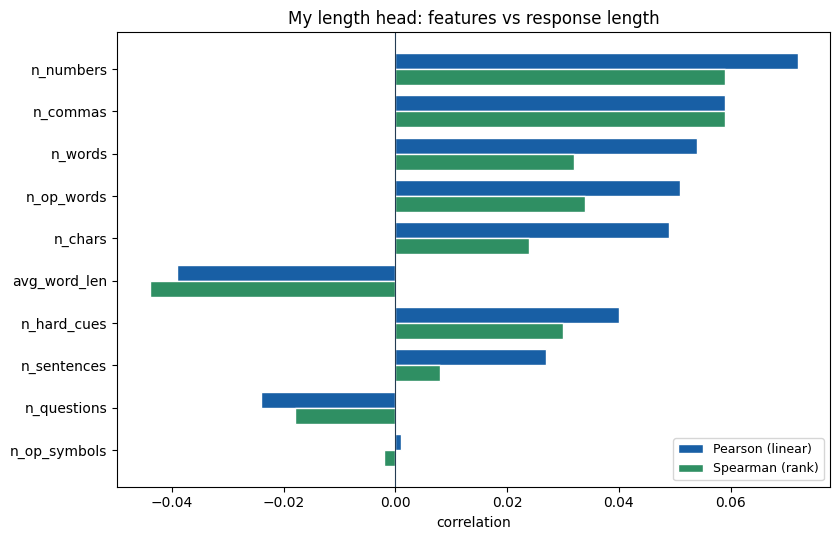

In [14]:
L = cdf[cdf.target=="mean_resp_len"].sort_values("max_abs")
y = np.arange(len(L)); h=0.38
fig,ax = plt.subplots(figsize=(8.5,5.5))
ax.barh(y+h/2, L.pearson, height=h, color=BLUE, edgecolor="white", label="Pearson (linear)")
ax.barh(y-h/2, L.spearman, height=h, color=GREEN, edgecolor="white", label="Spearman (rank)")
ax.axvline(0,color=DARK,lw=0.8); ax.set_yticks(y); ax.set_yticklabels(L.feature)
ax.set_title("My length head: features vs response length"); ax.set_xlabel("correlation")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.savefig("fig1_length.png",dpi=150,bbox_inches="tight"); plt.show()

**Difficulty curve** — features vs pass_rate.

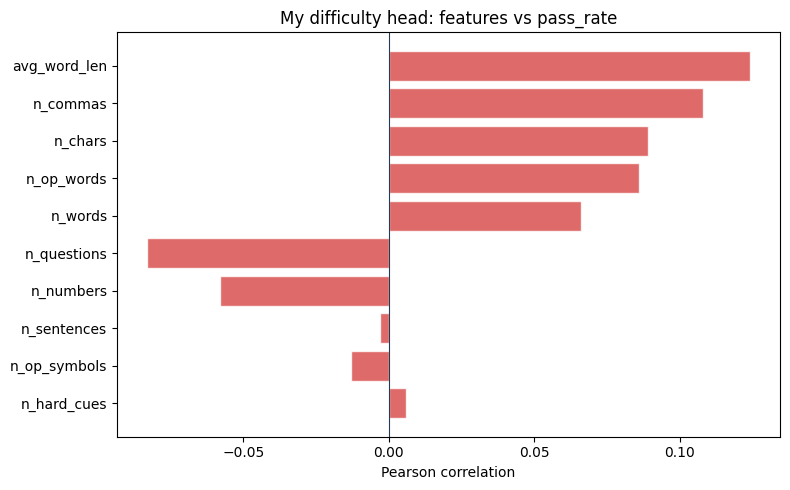

In [15]:
if "pass_rate" in cdf.target.values and cdf[cdf.target=="pass_rate"].pearson.notna().any():
    D = cdf[cdf.target=="pass_rate"].sort_values("max_abs")
    fig,ax = plt.subplots(figsize=(8,5))
    ax.barh(D.feature, D.pearson, color=RED, alpha=0.8, edgecolor="white")
    ax.axvline(0,color=DARK,lw=0.8)
    ax.set_title("My difficulty head: features vs pass_rate"); ax.set_xlabel("Pearson correlation")
    plt.tight_layout(); plt.savefig("fig2_difficulty.png",dpi=150,bbox_inches="tight"); plt.show()
else:
    print("Difficulty correlations are NaN (flat target) — nothing to plot. See Section 7 verdict.")

## 12. Status

- Pipeline (features + correlator) validated end-to-end; self-test recovers a planted signal.
- Length top features + difficulty top features read from Section 9 (once Section 7 = UNBLOCKED).
- Redundancy test = the go/no-go on my two-head design.
- Blocked-check is Section 7: if difficulty is flat, that's Samuel's run, not my predictor.
- Next: lock top-3 features per head, hand schema to Samuel; perplexity feature only if difficulty
  stays weakly predicted (and locally on my 5060 first, no OpenRouter spend).